In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score
)

import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)

In [2]:
# Load HaluEval feature matrix
df = pd.read_csv("../data/processed/halueval_features.csv")
print("Shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())

FEATURE_COLS = [
    "response_len", "hedge_count", "rouge1", "rougeL",
    "bleu", "sem_sim", "bertscore_f1", "nli_score"
]

X = df[FEATURE_COLS].values
y = df["label"].values

print(f"\nFeature matrix: {X.shape}")
print(f"Class balance: {y.mean():.3f}")

Shape: (5000, 13)

Label distribution:
label
0    2500
1    2500
Name: count, dtype: int64

Feature matrix: (5000, 8)
Class balance: 0.500


In [3]:
# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")
print(f"\nTrain label balance: {y_train.mean():.3f}")
print(f"Test label balance:  {y_test.mean():.3f}")

Train size: 4000 rows
Test size:  1000 rows

Train label balance: 0.500
Test label balance:  0.500


In [4]:
# Define all 6 classifiers with pipelines
pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(probability=True, random_state=42))
    ]),
    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            random_state=42, eval_metric="logloss",
            verbosity=0, use_label_encoder=False
        ))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ])
}

In [5]:
# Baseline evaluation: Stratified 5-fold CV
# Untuned models — establishes baseline performance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_results = {}

print("Running 5-fold CV on untuned models...\n")
for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=["accuracy", "f1", "roc_auc"],
        return_train_score=False
    )
    baseline_results[name] = {
        "Accuracy": scores["test_accuracy"].mean(),
        "F1": scores["test_f1"].mean(),
        "AUC": scores["test_roc_auc"].mean(),
        "Acc Std": scores["test_accuracy"].std(),
        "F1 Std": scores["test_f1"].std(),
    }
    print(f"{name}: F1={baseline_results[name]['F1']:.4f} | "
          f"AUC={baseline_results[name]['AUC']:.4f} | "
          f"Acc={baseline_results[name]['Accuracy']:.4f}")

baseline_df = pd.DataFrame(baseline_results).T.sort_values("F1", ascending=False)
print("\nBaseline Results (sorted by F1):")
print(baseline_df.round(4))

Running 5-fold CV on untuned models...

Logistic Regression: F1=0.9456 | AUC=0.9798 | Acc=0.9465
SVM: F1=0.9476 | AUC=0.9860 | Acc=0.9480
Decision Tree: F1=0.9324 | AUC=0.9327 | Acc=0.9328
Random Forest: F1=0.9558 | AUC=0.9862 | Acc=0.9555
Gradient Boosting: F1=0.9568 | AUC=0.9877 | Acc=0.9570
KNN: F1=0.9274 | AUC=0.9646 | Acc=0.9287

Baseline Results (sorted by F1):
                     Accuracy      F1     AUC  Acc Std  F1 Std
Gradient Boosting      0.9570  0.9568  0.9877   0.0064  0.0063
Random Forest          0.9555  0.9558  0.9862   0.0101  0.0098
SVM                    0.9480  0.9476  0.9860   0.0089  0.0089
Logistic Regression    0.9465  0.9456  0.9798   0.0093  0.0093
Decision Tree          0.9328  0.9324  0.9327   0.0125  0.0126
KNN                    0.9288  0.9274  0.9646   0.0060  0.0062


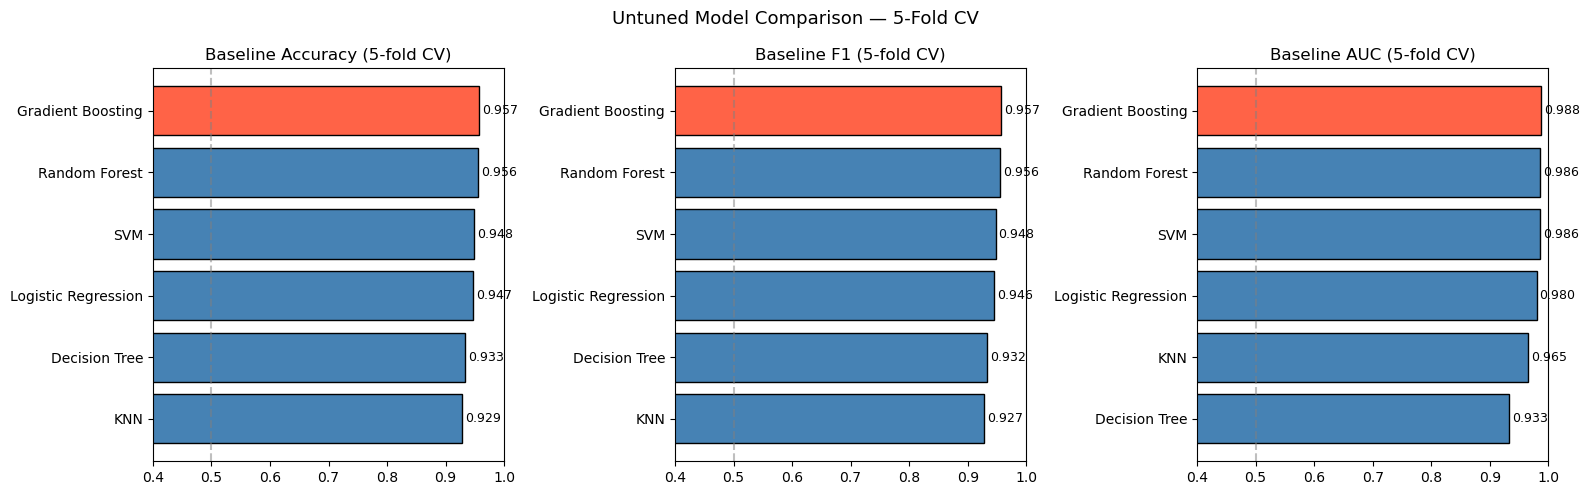

In [6]:
# Visualize baseline results
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["Accuracy", "F1", "AUC"]

for i, metric in enumerate(metrics):
    vals = baseline_df[metric].sort_values()
    colors = ["tomato" if v == vals.max() else "steelblue" for v in vals]
    axes[i].barh(vals.index, vals.values, color=colors, edgecolor="black")
    axes[i].set_title(f"Baseline {metric} (5-fold CV)")
    axes[i].set_xlim(0.4, 1.0)
    axes[i].axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
    for j, v in enumerate(vals.values):
        axes[i].text(v + 0.005, j, f"{v:.3f}", va="center", fontsize=9)

plt.suptitle("Untuned Model Comparison — 5-Fold CV", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Hyperparameter tuning
# Logistic Regression
lr_grid = {
    "clf__C" : [0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2"],
    "clf__solver" : ["liblinear"]
}
lr_search = GridSearchCV(
    pipelines["Logistic Regression"], lr_grid,
    cv=cv, scoring="f1", n_jobs=-1, verbose=0
)
lr_search.fit(X_train, y_train)
print(f"LR best params:{lr_search.best_params_}")
print(f"LR best CV F1:{lr_search.best_score_:.4f}\n")

LR best params:{'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
LR best CV F1:0.9458



In [8]:
# SVM 
svm_grid = {
    "clf__C" : [0.1, 1, 10],
    "clf__kernel": ["rbf", "linear"],
    "clf__gamma" : ["scale", "auto"]
}
svm_search = GridSearchCV(
    pipelines["SVM"], svm_grid,
    cv=cv, scoring="f1", n_jobs=-1, verbose=0
)
svm_search.fit(X_train, y_train)
print(f"SVM best params: {svm_search.best_params_}")
print(f"SVM best CV F1: {svm_search.best_score_:.4f}\n")

SVM best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
SVM best CV F1: 0.9531



In [9]:
# Decision Tree
dt_grid = {
    "clf__max_depth" : [3, 5, 10, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__criterion" : ["gini", "entropy"]
}
dt_search = GridSearchCV(
    pipelines["Decision Tree"], dt_grid,
    cv=cv, scoring="f1", n_jobs=-1, verbose=0
)
dt_search.fit(X_train, y_train)
print(f"DT best params: {dt_search.best_params_}")
print(f"DT best CV F1: {dt_search.best_score_:.4f}\n")

DT best params: {'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__min_samples_split': 10}
DT best CV F1: 0.9507



In [10]:
# Random Forest
rf_param_dist = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth" : [5, 10, 20, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__max_features": ["sqrt", "log2"]
}
rf_search = RandomizedSearchCV(
    pipelines["Random Forest"], rf_param_dist,
    n_iter=20, cv=cv, scoring="f1",
    random_state=42, n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)
print(f"RF best params:{rf_search.best_params_}")
print(f"RF best CV F1: {rf_search.best_score_:.4f}\n")

RF best params:{'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__max_features': 'log2', 'clf__max_depth': 20}
RF best CV F1: 0.9566



In [11]:
# Gradient Boosting
xgb_param_dist = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__subsample": [0.7, 0.8, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 1.0]
}
xgb_search = RandomizedSearchCV(
    pipelines["Gradient Boosting"], xgb_param_dist,
    n_iter=20, cv=cv, scoring="f1",
    random_state=42, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)
print(f"XGB best params:{xgb_search.best_params_}")
print(f"XGB best CV F1:{xgb_search.best_score_:.4f}\n")

XGB best params:{'clf__subsample': 1.0, 'clf__n_estimators': 200, 'clf__max_depth': 3, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 1.0}
XGB best CV F1:0.9597



In [12]:
# KNN
knn_grid = {
    "clf__n_neighbors": [3, 5, 7, 11, 15],
    "clf__weights": ["uniform", "distance"],
    "clf__metric": ["euclidean", "manhattan"]
}
knn_search = GridSearchCV(
    pipelines["KNN"], knn_grid,
    cv=cv, scoring="f1", n_jobs=-1, verbose=0
)
knn_search.fit(X_train, y_train)
print(f"KNN best params:{knn_search.best_params_}")
print(f"KNN best CV F1:{knn_search.best_score_:.4f}")

KNN best params:{'clf__metric': 'manhattan', 'clf__n_neighbors': 7, 'clf__weights': 'distance'}
KNN best CV F1:0.9282


In [13]:
# Tuned model evaluation on held-out test set
tuned_models = {
    "Logistic Regression": lr_search.best_estimator_,
    "SVM" : svm_search.best_estimator_,
    "Decision Tree" : dt_search.best_estimator_,
    "Random Forest" : rf_search.best_estimator_,
    "Gradient Boosting" : xgb_search.best_estimator_,
    "KNN" : knn_search.best_estimator_
}

tuned_results = {}
for name, model in tuned_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    tuned_results[name] = {
        "Accuracy" : accuracy_score(y_test, y_pred),
        "F1" : f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall" : recall_score(y_test, y_pred),
        "AUC" : roc_auc_score(y_test, y_proba)
    }

tuned_df = pd.DataFrame(tuned_results).T.sort_values("F1", ascending=False)
print("Tuned Model Results on Test Set:")
print(tuned_df.round(4))

Tuned Model Results on Test Set:
                     Accuracy      F1  Precision  Recall     AUC
SVM                     0.960  0.9597     0.9675   0.952  0.9909
Random Forest           0.958  0.9581     0.9562   0.960  0.9874
Gradient Boosting       0.956  0.9557     0.9615   0.950  0.9907
Decision Tree           0.947  0.9477     0.9357   0.960  0.9837
Logistic Regression     0.947  0.9458     0.9686   0.924  0.9798
KNN                     0.946  0.9455     0.9551   0.936  0.9759


In [14]:
# Tuned vs untuned comparison table
comparison = pd.DataFrame({
    "Baseline F1" : baseline_df["F1"],
    "Tuned F1" : tuned_df["F1"],
}).round(4)
comparison["Improvement"] = (comparison["Tuned F1"] - comparison["Baseline F1"]).round(4)
comparison = comparison.sort_values("Tuned F1", ascending=False)

print("Tuned vs Untuned F1 Comparison:")
print(comparison)

Tuned vs Untuned F1 Comparison:
                     Baseline F1  Tuned F1  Improvement
SVM                       0.9476    0.9597       0.0121
Random Forest             0.9558    0.9581       0.0023
Gradient Boosting         0.9568    0.9557      -0.0011
Decision Tree             0.9324    0.9477       0.0153
Logistic Regression       0.9456    0.9458       0.0002
KNN                       0.9274    0.9455       0.0181


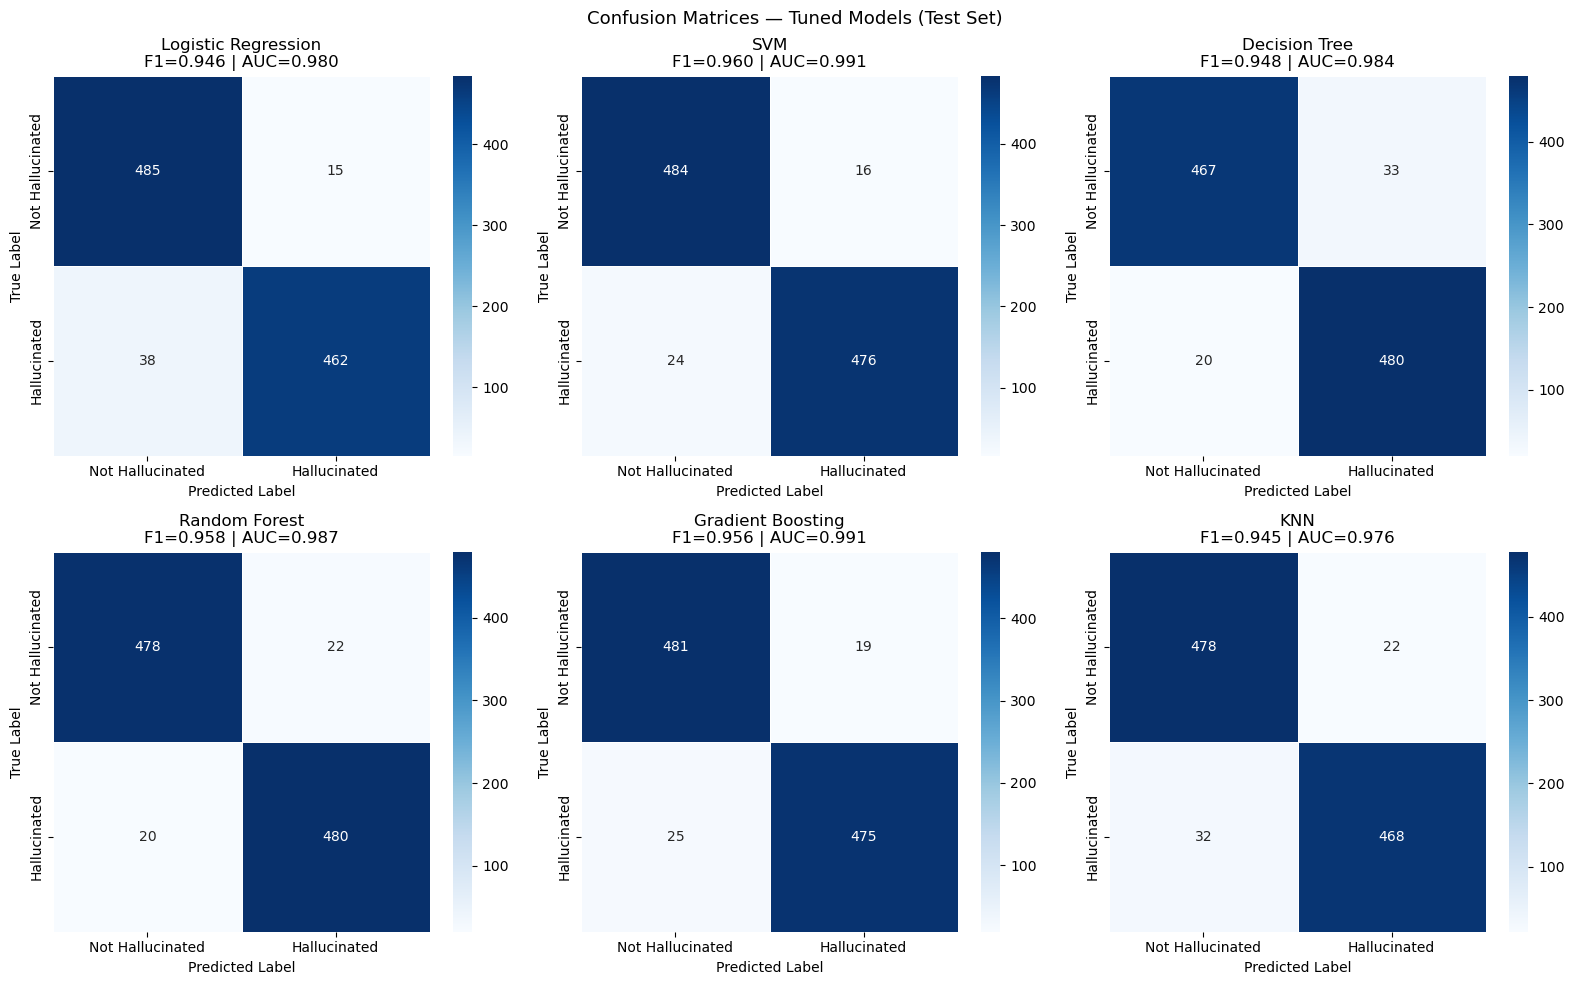

In [15]:
# Confusion matrices for all tuned models
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(tuned_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", ax=axes[i],
        cmap="Blues", linewidths=0.5,
        xticklabels=["Not Hallucinated", "Hallucinated"],
        yticklabels=["Not Hallucinated", "Hallucinated"]
    )
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    axes[i].set_title(f"{name}\nF1={f1:.3f} | AUC={auc:.3f}")
    axes[i].set_ylabel("True Label")
    axes[i].set_xlabel("Predicted Label")

plt.suptitle("Confusion Matrices — Tuned Models (Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

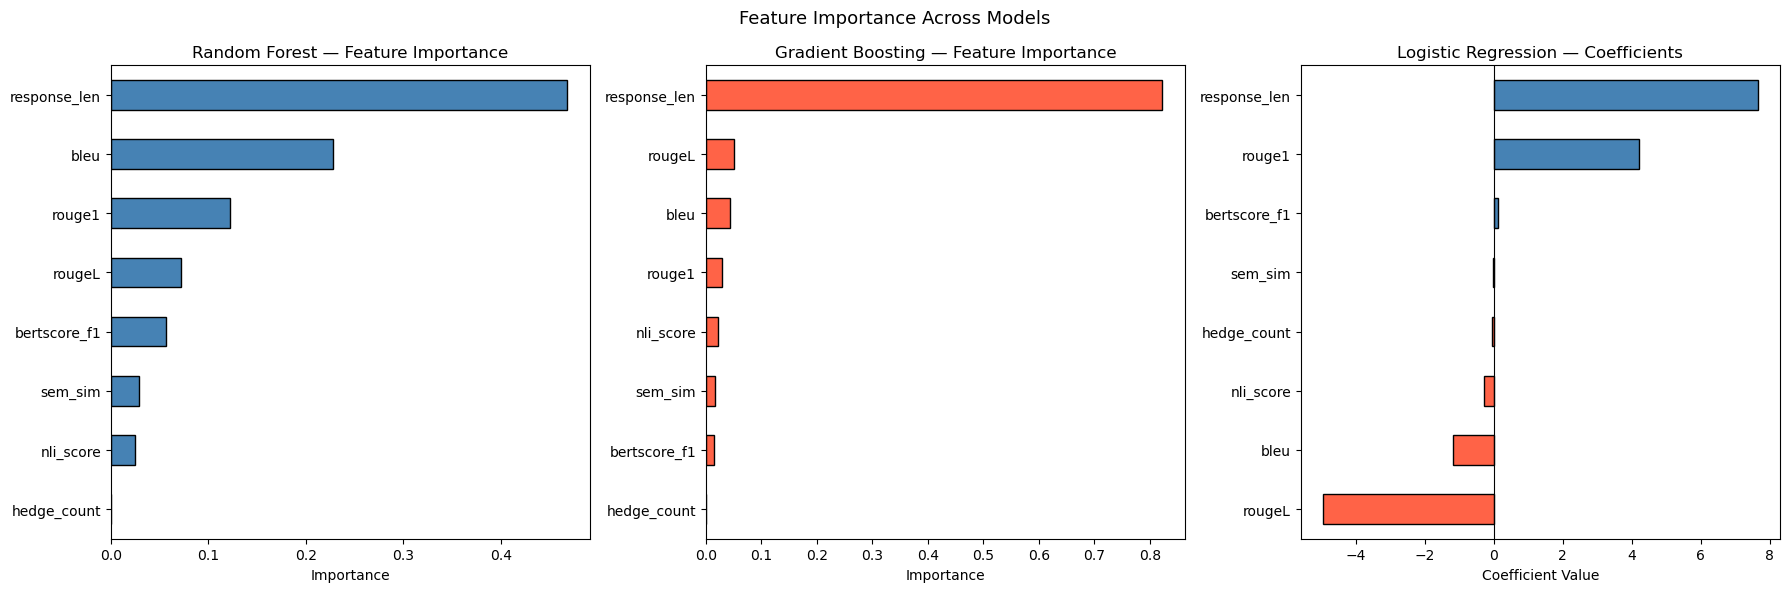

In [16]:
# Feature importance analysis
# Random Forest and Gradient Boosting native importance
# Logistic Regression coefficients
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Random Forest
rf_imp = rf_search.best_estimator_.named_steps["clf"].feature_importances_
rf_imp_df = pd.Series(rf_imp, index=FEATURE_COLS).sort_values(ascending=True)
rf_imp_df.plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Random Forest — Feature Importance")
axes[0].set_xlabel("Importance")

# Gradient Boosting
xgb_imp = xgb_search.best_estimator_.named_steps["clf"].feature_importances_
xgb_imp_df = pd.Series(xgb_imp, index=FEATURE_COLS).sort_values(ascending=True)
xgb_imp_df.plot(kind="barh", ax=axes[1], color="tomato", edgecolor="black")
axes[1].set_title("Gradient Boosting — Feature Importance")
axes[1].set_xlabel("Importance")

# Logistic Regression coefficients
lr_coef = lr_search.best_estimator_.named_steps["clf"].coef_[0]
lr_coef_df = pd.Series(lr_coef, index=FEATURE_COLS).sort_values(ascending=True)
colors_lr = ["tomato" if c < 0 else "steelblue" for c in lr_coef_df]
lr_coef_df.plot(kind="barh", ax=axes[2], color=colors_lr, edgecolor="black")
axes[2].set_title("Logistic Regression — Coefficients")
axes[2].set_xlabel("Coefficient Value")
axes[2].axvline(0, color="black", linewidth=0.8)

plt.suptitle("Feature Importance Across Models", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Cross-model analysis on TruthfulQA
# Apply best classifier to each LLM's feature matrix
# Compare hallucination rates across Mistral, Groq, Llama HF
responses_features = pd.read_csv("../data/processed/llm_responses_features.csv")

# Use best tuned model (highest F1 on test set)
best_model_name = tuned_df["F1"].idxmax()
best_model = tuned_models[best_model_name]
print(f"Best model: {best_model_name}")

model_cols = {
    "Mistral Small" : [f"mistral_{f}" for f in FEATURE_COLS],
    "Llama 3.3 70B" : [f"groq_{f}" for f in FEATURE_COLS],
    "Llama 3.1 8B" : [f"llama_hf_{f}" for f in FEATURE_COLS]
}

hal_rates = {}
for model_name, cols in model_cols.items():
    X_llm = responses_features[cols].values
    preds = best_model.predict(X_llm)
    hal_rate = preds.mean()
    hal_rates[model_name] = hal_rate
    print(f"{model_name}: {hal_rate:.1%} hallucination rate")

Best model: SVM
Mistral Small: 100.0% hallucination rate
Llama 3.3 70B: 99.8% hallucination rate
Llama 3.1 8B: 99.5% hallucination rate


In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Test 1: response_len only
X_len_only = df[["response_len"]].values
scores_len = cross_val_score(
    Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression())]),
    X_len_only, y, cv=5, scoring="f1"
)
print(f"F1 using response_len ONLY:{scores_len.mean():.4f} ± {scores_len.std():.4f}")

# Test 2: all features except response_len
no_len_cols = [f for f in FEATURE_COLS if f != "response_len"]
X_no_len = df[no_len_cols].values
scores_no_len = cross_val_score(
    Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression())]),
    X_no_len, y, cv=5, scoring="f1"
)
print(f"F1 without response_len: {scores_no_len.mean():.4f} ± {scores_no_len.std():.4f}")

# Test 3: all features (reference)
scores_all = cross_val_score(
    Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression())]),
    X, y, cv=5, scoring="f1"
)
print(f"F1 with all features: {scores_all.mean():.4f} ± {scores_all.std():.4f}")

F1 using response_len ONLY:0.9407 ± 0.0093
F1 without response_len: 0.8400 ± 0.0064
F1 with all features: 0.9464 ± 0.0085


## Key Finding: Length Bias in HaluEval QA Subset

Ablation analysis reveals that response_len alone achieves F1=0.9407,nearly identical to the full feature set (F1=0.9464). Removing response_len
drops F1 to 0.8400 — a 10.6 point reduction. Feature importance plots confirm this finding across all three tree-based models.

This indicates classifiers are learning a structural artifact of the QA subset
rather than genuine semantic hallucination patterns. HaluEval QA answers are
short (mean 2.3 words) while hallucinated answers are longer sentences(mean 10.9 words), making length trivially discriminative.

We therefore switch to the HaluEval summarization subset where both correct
and hallucinated summaries are comparable in length, requiring classifiers to learn genuine semantic differences.